In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import os
import torch
from tqdm.auto import tqdm

from JacobianODE.jacobians import (
    load_config,
    initialize_config,
    seed_everything,
    make_trajectories,
    postprocess_data,
)
from JacobianODE.fnn import loss_amplification, loss_false
from JacobianODE.jacobians.data import embed_signal_torch

In [3]:
# Standard Lorenz config (data=dysts defaults to Lorenz, 32 trials, 12 periods, 100 pts/period)
cfg = load_config(overrides=[
    "data=dysts",
    # "data.postprocessing.obs_noise=0.05",
    "data.postprocessing.obs_noise=0.01",
    f"training.logger.save_dir={os.getcwd()}",
])
cfg = initialize_config(cfg)
seed_everything(cfg.data.flow.random_state + cfg.training.run_number)

eq, sol, dt = make_trajectories(cfg, verbose=True)
values_raw = sol["values"]  # shape (n_trials, n_timepoints, n_dims)
result = postprocess_data(cfg, values_raw)
values = result.values
print(f"Loaded Lorenz: {values.shape}, dt={dt:.4f}")
x = torch.from_numpy(values)[..., [0]]
print(f"Generate x: {x.shape}")

Loaded Lorenz: (32, 1200, 3), dt=0.0150
Generate x: torch.Size([32, 1200, 1])


In [16]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
amplification_losses = {}
fnn_losses = {}
N_DELAYS_VALS = np.arange(1, 51)
INTERVAL_VALS = np.arange(1, 21)

iterator = tqdm(total=len(N_DELAYS_VALS) * len(INTERVAL_VALS))

for n_delays in N_DELAYS_VALS:
    for delay_interval in INTERVAL_VALS:
        if x.shape[1] - (n_delays - 1) * delay_interval <= 0: # use at least half the data
            iterator.update(1)
            continue
        x_embedded = embed_signal_torch(x, n_delays, delay_interval)
        x_embedded = x_embedded.to(device)
        x_data = x_embedded[..., :x.shape[-1]]

        if x_embedded.shape[1] < x.shape[1]*(0.5): # use at least half the data
            iterator.update(1)
            continue

        loss = loss_amplification(x_embedded, x_data.to(device), max_T=30, n_neighbors=10,normalize=True)
        amplification_losses[(n_delays, delay_interval)] = loss.item()
        loss_fnn = loss_false(
                        x_embedded.reshape(-1, x_embedded.shape[-1]), 
                        k=1, normalize=True, 
                        use_pca=True, 
                        elementwise_regularization=True, 
                        return_fnn_weights=False,
                        n_samples=1024
                    )
        fnn_losses[(n_delays, delay_interval)] = loss_fnn.item()

        iterator.update(1)
iterator.close()

  0%|          | 0/1000 [00:00<?, ?it/s]

/tmp/ipykernel_3404074/2554729816.py:19: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("viridis").copy()


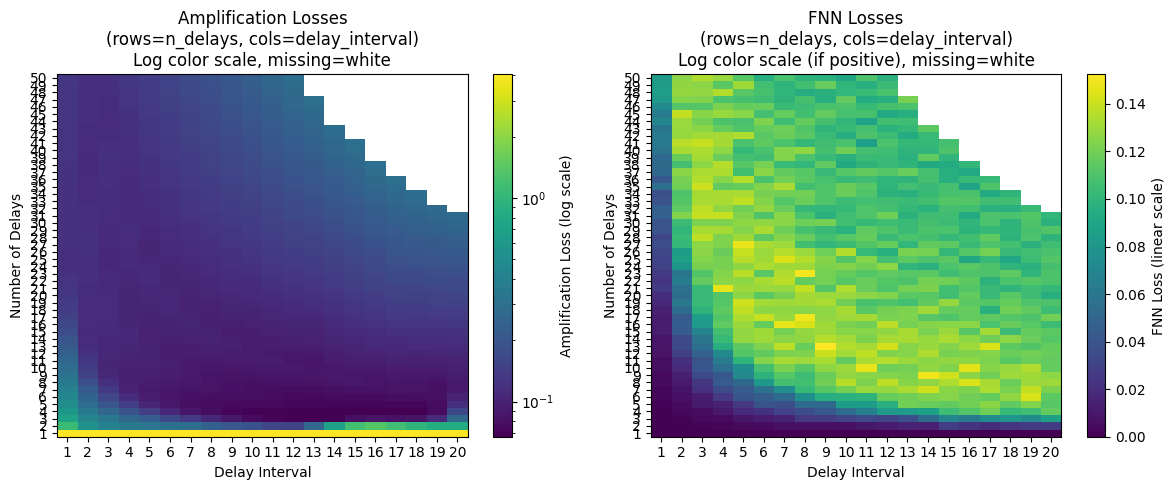

In [17]:
import numpy as np
from matplotlib.colors import LogNorm
import matplotlib.pyplot as plt

# Convert the amplification_losses and fnn_losses dicts to 2D arrays for plotting
n_delays_max = max(N_DELAYS_VALS)
interval_max = max(INTERVAL_VALS)

# Use np.full with np.nan, so missing entries are np.nan (shows up as white)
amplification_loss_matrix = np.full((n_delays_max, interval_max), np.nan)
fnn_loss_matrix = np.full((n_delays_max, interval_max), np.nan)
for (n_delays, delay_interval), loss in amplification_losses.items():
    amplification_loss_matrix[n_delays-1, delay_interval-1] = float(loss)
for (n_delays, delay_interval), loss in fnn_losses.items():
    fnn_loss_matrix[n_delays-1, delay_interval-1] = float(loss)

# Mask nan values to display them as white by using a colormap with nan color set to white
from matplotlib import cm
cmap = cm.get_cmap("viridis").copy()
cmap.set_bad(color='white')

# Normalization for log scale (amplification loss)
non_nan_amp = np.isfinite(amplification_loss_matrix)
if np.any(non_nan_amp):
    vmin_amp = np.nanmin(amplification_loss_matrix)
    vmax_amp = np.nanmax(amplification_loss_matrix)
else:
    vmin_amp, vmax_amp = 1, 10  # fallback

# Normalization for fnn (can be log if strictly positive, else linear)
non_nan_fnn = np.isfinite(fnn_loss_matrix)
if np.any(non_nan_fnn):
    vmin_fnn = np.nanmin(fnn_loss_matrix)
    vmax_fnn = np.nanmax(fnn_loss_matrix)
else:
    vmin_fnn, vmax_fnn = 1e-2, 1  # fallback

# Try using a linear color scale if no negative/zero values, else fallback to LogNorm
fnn_strictly_positive = np.nanmin(fnn_loss_matrix) > 0
norm_fnn = LogNorm(vmin=max(vmin_fnn, 1e-8), vmax=vmax_fnn) if fnn_strictly_positive else None

fig, axs = plt.subplots(1, 2, figsize=(12, 5))

im0 = axs[0].imshow(
    np.ma.masked_invalid(amplification_loss_matrix),
    origin="lower",
    aspect="auto",
    cmap=cmap,
    norm=LogNorm(vmin=vmin_amp, vmax=vmax_amp),
)
cbar0 = plt.colorbar(im0, ax=axs[0], label='Amplification Loss (log scale)')

im1 = axs[1].imshow(
    np.ma.masked_invalid(fnn_loss_matrix),
    origin="lower",
    aspect="auto",
    cmap=cmap,
    norm=norm_fnn,
)
if fnn_strictly_positive:
    cbar1 = plt.colorbar(im1, ax=axs[1], label='FNN Loss (log scale)')
else:
    cbar1 = plt.colorbar(im1, ax=axs[1], label='FNN Loss (linear scale)')

# Set tick labels for both subplots
for ax in axs:
    ax.set_xticks(np.arange(interval_max))
    ax.set_yticks(np.arange(n_delays_max))
    ax.set_xticklabels(np.arange(1, interval_max + 1))
    ax.set_yticklabels(np.arange(1, n_delays_max + 1))
    ax.set_xlabel("Delay Interval")
    ax.set_ylabel("Number of Delays")

axs[0].set_title("Amplification Losses\n(rows=n_delays, cols=delay_interval)\nLog color scale, missing=white")
axs[1].set_title("FNN Losses\n(rows=n_delays, cols=delay_interval)\nLog color scale (if positive), missing=white")

plt.tight_layout()
plt.show()

In [19]:
# Find the (n_delays, delay_interval) that gives the minimum amplification loss
best_amp_params = min(amplification_losses, key=amplification_losses.get)
best_amp_n_delays, best_amp_delay_interval = best_amp_params
best_amp_loss = amplification_losses[best_amp_params]

print(f"Best amplification loss: {best_amp_loss:.5g} at n_delays={best_amp_n_delays}, delay_interval={best_amp_delay_interval}")

# Generate the embedding with these optimal parameters for amplification loss
best_amp_x_embedded = embed_signal_torch(x, best_amp_n_delays, best_amp_delay_interval)

# Also find the minimum amplification loss when delay_interval == 1
amp_candidates_delay1 = {k: v for k, v in amplification_losses.items() if k[1] == 1}
if amp_candidates_delay1:
    best_amp_params_delay1 = min(amp_candidates_delay1, key=amp_candidates_delay1.get)
    best_amp_n_delays_delay1, best_amp_delay_interval_delay1 = best_amp_params_delay1
    best_amp_loss_delay1 = amplification_losses[best_amp_params_delay1]
    print(f"Best amplification loss (delay_interval=1): {best_amp_loss_delay1:.5g} at n_delays={best_amp_n_delays_delay1}, delay_interval={best_amp_delay_interval_delay1}")

    # Generate the embedding with these optimal parameters for amplification loss at delay_interval=1
    best_amp_x_embedded_delay1 = embed_signal_torch(x, best_amp_n_delays_delay1, best_amp_delay_interval_delay1)
else:
    print("No amplification losses found with delay_interval=1; skipping best amplification embedding with delay_interval=1.")
    best_amp_x_embedded_delay1 = None

# Find the (n_delays, delay_interval) that gives the minimum FNN loss (excluding n_delays=1)
if len(fnn_losses) > 0:
    # Exclude n_delays == 1 from candidates
    fnn_candidates = {k: v for k, v in fnn_losses.items() if k[0] > 1}
    if fnn_candidates:
        best_fnn_params = min(fnn_candidates, key=fnn_candidates.get)
        best_fnn_n_delays, best_fnn_delay_interval = best_fnn_params
        best_fnn_loss = fnn_losses[best_fnn_params]
        print(f"Best FNN loss (n_delays > 1): {best_fnn_loss:.5g} at n_delays={best_fnn_n_delays}, delay_interval={best_fnn_delay_interval}")

        # Generate the embedding with these optimal parameters for FNN loss
        best_fnn_x_embedded = embed_signal_torch(x, best_fnn_n_delays, best_fnn_delay_interval)
    else:
        print("No FNN losses found with n_delays > 1; skipping best FNN embedding.")
        best_fnn_x_embedded = None
else:
    print("No FNN losses found; skipping best FNN embedding.")
    best_fnn_x_embedded = None

Best amplification loss: 0.067196 at n_delays=3, delay_interval=13
Best amplification loss (delay_interval=1): 0.11811 at n_delays=25, delay_interval=1
Best FNN loss (n_delays > 1): 0.00037092 at n_delays=2, delay_interval=1


In [20]:
# --- Participation ratio and PCA projection for best amplification embedding ---
amp_emb_pca = None
if 'best_amp_x_embedded' in locals() and best_amp_x_embedded is not None:
    amp_emb_flat = best_amp_x_embedded.reshape(-1, best_amp_x_embedded.shape[-1])
    amp_emb_flat_centered = amp_emb_flat - torch.mean(amp_emb_flat, dim=0, keepdim=True)
    amp_emb_cov = torch.cov(amp_emb_flat_centered.T)
    amp_emb_eigvals, amp_emb_eigvecs = torch.linalg.eigh(amp_emb_cov)
    amp_emb_eigvals = amp_emb_eigvals.flip(dims=(0,))
    amp_emb_eigvecs = amp_emb_eigvecs.flip(dims=(1,))
    amp_emb_pr = (amp_emb_eigvals.sum())**2 / (amp_emb_eigvals**2).sum()
    print(f"Amp Chosen Embedding Participation Ratio: {amp_emb_pr.item():.3f}")
    amp_emb_pca = amp_emb_flat_centered @ amp_emb_eigvecs

# --- Participation ratio and PCA projection for best amplification embedding with delay_interval=1 ---
amp_emb_pca_delay1 = None
if 'best_amp_x_embedded_delay1' in locals() and best_amp_x_embedded_delay1 is not None:
    amp_emb_flat_delay1 = best_amp_x_embedded_delay1.reshape(-1, best_amp_x_embedded_delay1.shape[-1])
    amp_emb_flat_centered_delay1 = amp_emb_flat_delay1 - torch.mean(amp_emb_flat_delay1, dim=0, keepdim=True)
    amp_emb_cov_delay1 = torch.cov(amp_emb_flat_centered_delay1.T)
    amp_emb_eigvals_delay1, amp_emb_eigvecs_delay1 = torch.linalg.eigh(amp_emb_cov_delay1)
    amp_emb_eigvals_delay1 = amp_emb_eigvals_delay1.flip(dims=(0,))
    amp_emb_eigvecs_delay1 = amp_emb_eigvecs_delay1.flip(dims=(1,))
    amp_emb_pr_delay1 = (amp_emb_eigvals_delay1.sum())**2 / (amp_emb_eigvals_delay1**2).sum()
    print(f"Amp Embedding (delay_interval=1) Participation Ratio: {amp_emb_pr_delay1.item():.3f}")
    amp_emb_pca_delay1 = amp_emb_flat_centered_delay1 @ amp_emb_eigvecs_delay1

# --- Participation ratio and PCA projection for best FNN embedding ---
fnn_emb_pca = None
if 'best_fnn_x_embedded' in locals() and best_fnn_x_embedded is not None:
    fnn_emb_flat = best_fnn_x_embedded.reshape(-1, best_fnn_x_embedded.shape[-1])
    fnn_emb_flat_centered = fnn_emb_flat - torch.mean(fnn_emb_flat, dim=0, keepdim=True)
    fnn_emb_cov = torch.cov(fnn_emb_flat_centered.T)
    fnn_emb_eigvals, fnn_emb_eigvecs = torch.linalg.eigh(fnn_emb_cov)
    fnn_emb_eigvals = fnn_emb_eigvals.flip(dims=(0,))
    fnn_emb_eigvecs = fnn_emb_eigvecs.flip(dims=(1,))
    fnn_emb_pr = (fnn_emb_eigvals.sum())**2 / (fnn_emb_eigvals**2).sum()
    print(f"FNN Chosen Embedding Participation Ratio: {fnn_emb_pr.item():.3f}")
    fnn_emb_pca = fnn_emb_flat_centered @ fnn_emb_eigvecs

Amp Chosen Embedding Participation Ratio: 1.327
Amp Embedding (delay_interval=1) Participation Ratio: 1.208
FNN Chosen Embedding Participation Ratio: 1.002


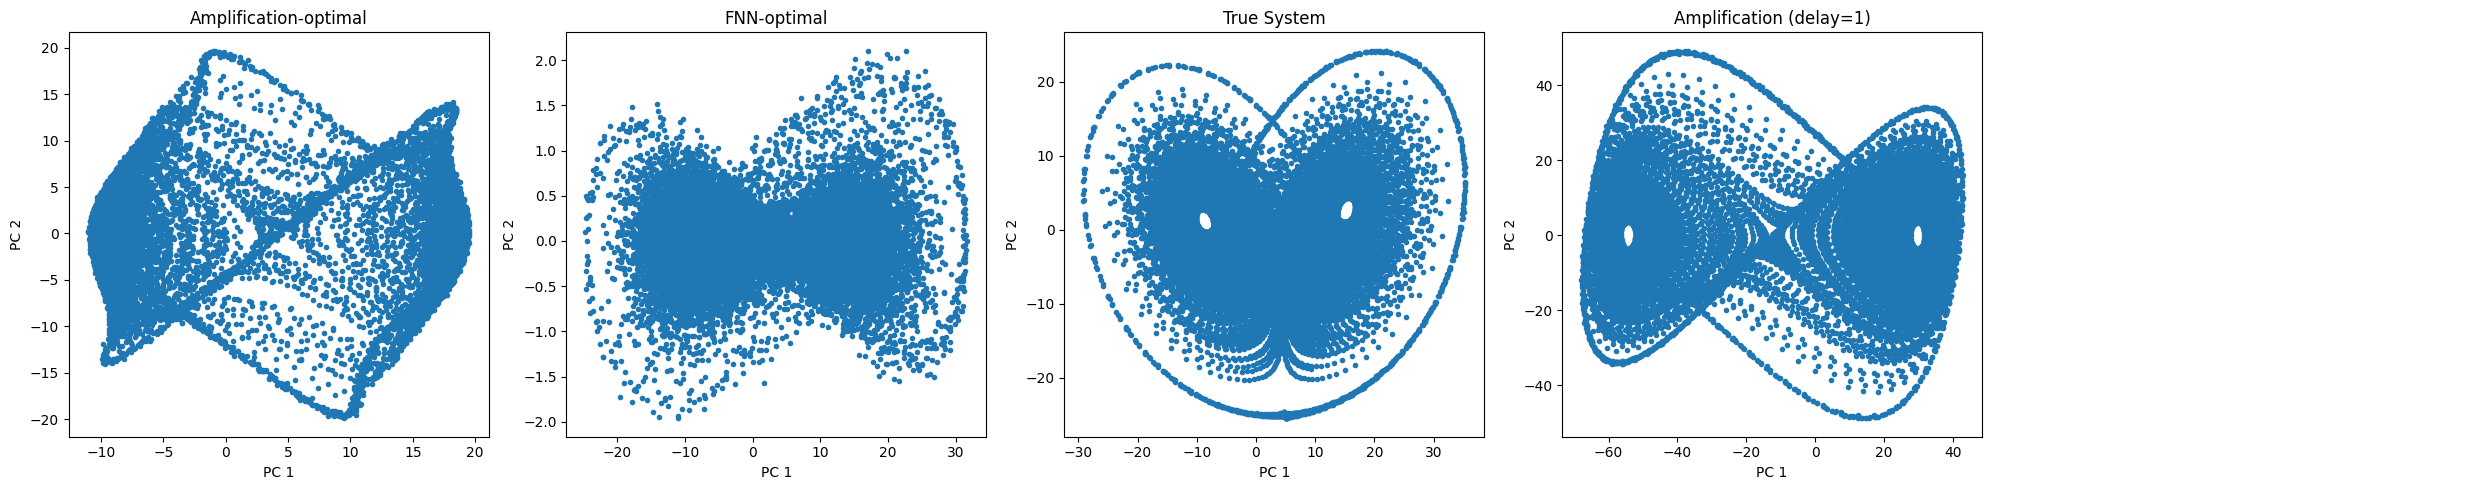

In [22]:
fig, axs = plt.subplots(1, 5, figsize=(25, 5))

# 1. Chosen amplification-optimal embedding (if available)
if amp_emb_pca is not None:
    axs[0].plot(amp_emb_pca[:, 0], amp_emb_pca[:, 1], '.')
    axs[0].set_title('Amplification-optimal')
    axs[0].set_xlabel('PC 1')
    axs[0].set_ylabel('PC 2')
else:
    axs[0].set_visible(False)
    axs[0].set_title('No Amplification-optimal')

# 2. FNN-optimal embedding (if available)
if fnn_emb_pca is not None:
    axs[1].plot(fnn_emb_pca[:, 0], fnn_emb_pca[:, 1], '.')
    axs[1].set_title('FNN-optimal')
    axs[1].set_xlabel('PC 1')
    axs[1].set_ylabel('PC 2')
else:
    axs[1].set_visible(False)
    axs[1].set_title('No FNN-optimal')

# 3. True system embedding PCA (recompute here from values_raw, if available)
if "values_raw" in locals():
    # Assume values_raw: (timesteps, features) torch tensor or numpy array
    if isinstance(values_raw, torch.Tensor):
        values_raw_flat = values_raw.reshape(-1, values_raw.shape[-1])
        mean = torch.mean(values_raw_flat, dim=0, keepdim=True)
        values_flat_centered = values_raw_flat - mean
        cov = torch.cov(values_flat_centered.T)
        eigvals, eigvecs = torch.linalg.eigh(cov)
        eigvecs = eigvecs.flip(dims=(1,))
        values_pca = values_flat_centered @ eigvecs
        values_pca_np = values_pca.detach().cpu().numpy()
    else:
        # Assume numpy
        values_raw_flat = values_raw.reshape(-1, values_raw.shape[-1])
        mean = values_raw_flat.mean(axis=0, keepdims=True)
        values_flat_centered = values_raw_flat - mean
        cov = np.cov(values_flat_centered.T)
        eigvals, eigvecs = np.linalg.eigh(cov)
        eigvecs = np.flip(eigvecs, axis=1)
        values_pca_np = values_flat_centered @ eigvecs
    axs[2].plot(values_pca_np[:, 0], values_pca_np[:, 1], '.')
    axs[2].set_title('True System')
    axs[2].set_xlabel('PC 1')
    axs[2].set_ylabel('PC 2')
else:
    axs[2].set_visible(False)
    axs[2].set_title('No True System Data')

# 4. Delay-1 amplification embedding PCA (if available)
if amp_emb_pca_delay1 is not None:
    axs[3].plot(amp_emb_pca_delay1[:, 0], amp_emb_pca_delay1[:, 1], '.')
    axs[3].set_title('Amplification (delay=1)')
    axs[3].set_xlabel('PC 1')
    axs[3].set_ylabel('PC 2')
else:
    axs[3].set_visible(False)
    axs[3].set_title('No Delay=1 Amplification')

# 5. For future: leave this panel empty or use as placeholder
axs[4].axis('off')

plt.tight_layout()
plt.show()